In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [262]:
import pandas as pd
import numpy as np
import torch
from numba import typeof
from sklearn.preprocessing import StandardScaler

from src.features import cycle
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks import EarlyStopping
import optuna
import torch
from darts.models import TFTModel
from optuna.integration import PyTorchLightningPruningCallback
from darts.models import TFTModel

In [263]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [264]:
def preprocessing_data(df, days_since_start = 0):
    df.columns = [col.replace(',', '.') for col in df.columns]
    df['days_since_start'] = (df['Дата'] - df['Дата'].min()).dt.days + days_since_start
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    df.rename(columns={'48-Воздух (0)': 'air_temp'}, inplace=True)

    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)

    df_long = pd.melt(
        df,
        id_vars=['Дата', 'air_temp', 'День', 'Месяц', 'Год', 'is_anomaly', 'day_of_year','Месяц_sin', 'Месяц_cos', 'day_of_year_sin' ,'day_of_year_cos', 'days_since_start'],
        var_name='sensor_name',
        value_name='temperature'
    )

    df_long['depth_val'] = df_long['sensor_name'].str.extract(r'\((.*?)\)')[0].astype(float)
    df_long = df_long.drop(columns=['sensor_name'])

    df_long = df_long.sort_values(by=['depth_val', 'Дата'])

    df_long['temperature'] = df_long.groupby('depth_val')['temperature'].transform(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )
    df_long['air_temp'] = df_long.groupby('depth_val')['air_temp'].transform(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )

    for window in [14, 60]:
        df_long[f'air_temp_ma_{window}d'] = df_long['air_temp'].rolling(window, min_periods=1).mean()

    df_long['depth_id'] = df_long['depth_val'].astype(str)

    return df_long


In [265]:
def create_darts_dataset(df):
    df['depth_id'] = df['depth_id'].astype('category').cat.codes
    targets = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols='temperature',
        static_cols=['depth_val']
    )

    past_covs = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols=['air_temp', 'is_anomaly','air_temp_ma_60d','air_temp_ma_14d']
    )

    future_covs = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols=[
            'Месяц_sin', 'Месяц_cos',
            'day_of_year_sin', 'day_of_year_cos',
            'День', 'Месяц', 'Год', 'day_of_year', 'days_since_start'
        ]
    )

    return targets, past_covs, future_covs

train_prep = preprocessing_data(df_train)
train_darts = create_darts_dataset(train_prep)

val_prep = preprocessing_data(df_val, days_since_start=len(df_train))
val_darts = create_darts_dataset(val_prep)

In [266]:
target_scaler = Scaler(scaler=StandardScaler())
past_air_scaler = Scaler(scaler=StandardScaler())
future_scaler = Scaler(scaler=StandardScaler())

train_targets, train_past, train_future = train_darts

t_scaled_targets = target_scaler.fit_transform(train_targets)

train_air = [ts['air_temp'] for ts in train_past]
scaled_t_air = past_air_scaler.fit_transform(train_air)
train_anomaly = [ts['is_anomaly'] for ts in train_past]
t_scaled_past = [air.stack(anom) for air, anom in zip(scaled_t_air, train_anomaly)]
t_scaled_future = future_scaler.fit_transform(train_future)


val_targets, val_past, val_future = val_darts
val_scaled_targets = target_scaler.transform(val_targets)
val_air = [ts['air_temp'] for ts in val_past]
scaled_v_air = past_air_scaler.transform(val_air)
val_anomaly = [ts['is_anomaly'] for ts in val_past]
v_scaled_past = [air.stack(anom) for air, anom in zip(scaled_v_air, val_anomaly)]

v_scaled_future = future_scaler.transform(val_future)

In [267]:
from pytorch_lightning.callbacks import TQDMProgressBar


class SilentValProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = super().init_validation_tqdm()
        bar.disable = True
        return bar
silent_progress_bar = SilentValProgressBar()

In [268]:
IN_LEN = 180
OUT_LEN = 180


def objective(trial):
    hidden_size = trial.suggest_categorical("hidden_size", [16, 32, 64])
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    num_attention_heads = trial.suggest_categorical("num_attention_heads", [2, 4, 8])
    dropout = trial.suggest_float("dropout", 0.05, 0.3, step=0.05)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    pruning_callback = PyTorchLightningPruningCallback(trial, monitor="val_loss")
    early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-5,
        mode="min"
    )

    model = TFTModel(
        input_chunk_length=IN_LEN,
        output_chunk_length=OUT_LEN,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        num_attention_heads=num_attention_heads,
        dropout=dropout,
        batch_size=batch_size,
        n_epochs=50,
        add_relative_index=True,
        add_encoders=None,
        random_state=42,
        loss_fn=torch.nn.MSELoss(),
        model_name=f"tft_optuna_trial_{trial.number}",
        save_checkpoints=False,
        pl_trainer_kwargs={"callbacks": [early_stopper, silent_progress_bar, pruning_callback]},
        optimizer_kwargs={"lr": lr}
    )


    model.fit(
        series=t_scaled_targets,
        past_covariates=t_scaled_past,
        future_covariates=t_scaled_future,
        val_series=val_scaled_targets,
        val_past_covariates=v_scaled_past,
        val_future_covariates=v_scaled_future,
        verbose=False
    )


    val_loss = model.trainer.callback_metrics.get("val_loss")

    if val_loss is None:
        raise ValueError("val_loss не найден в callback_metrics. Проверьте параметры обучения.")

    return float(val_loss)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Лучшие параметры:", study.best_params)
print("Лучший val_loss:", study.best_value)

[I 2026-05-27 13:37:54,095] A new study created in memory with name: no-name-19c5e902-8faf-4fbf-b467-ccad084e2cc1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      |

Epoch 6: 100%|██████████| 123/123 [00:53<00:00,  2.29it/s, train_loss=0.0158, val_loss=0.0531]

[I 2026-05-27 13:44:11,055] Trial 0 finished with value: 0.05306050903804063 and parameters: {'hidden_size': 32, 'lstm_layers': 1, 'num_attention_heads': 2, 'dropout': 0.05, 'batch_size': 128, 'lr': 0.00016649403688445566}. Best is trial 0 with value: 0.05306050903804063.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 3.3 K  | train
7  | encoder_vsn

Epoch 6: 100%|██████████| 245/245 [01:22<00:00,  2.97it/s, train_loss=0.00384, val_loss=0.0384]

...

[I 2026-05-27 16:38:07,301] Trial 18 finished with value: 0.050319308067360576 and parameters: {'hidden_size': 64, 'lstm_layers': 3, 'num_attention_heads': 8, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.0003102509847228817}. Best is trial 3 with value: 0.024545120992790527.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.1 K  | train
7  | encoder_vsn                       | _VariableSelectionNetwork        | 9.0 K  | train
8  | decoder_vsn                       | _VariableSelectionNetwork        | 6.6 K  

Epoch 4: 100%|██████████| 490/490 [01:15<00:00,  6.48it/s, train_loss=0.00984, val_loss=0.036] 

[I 2026-05-27 16:44:25,884] Trial 19 finished with value: 0.036028124303614156 and parameters: {'hidden_size': 16, 'lstm_layers': 3, 'num_attention_heads': 2, 'dropout': 0.2, 'batch_size': 32, 'lr': 0.0009467368521743206}. Best is trial 3 with value: 0.024545120992790527.



Лучшие параметры: {'hidden_size': 32, 'lstm_layers': 3, 'num_attention_heads': 4, 'dropout': 0.25, 'batch_size': 128, 'lr': 0.0013853619205769605}
Лучший val_loss: 0.024545120992790527


In [273]:
early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-5,
        mode="min"
    )

model = TFTModel(
        input_chunk_length=IN_LEN,
        output_chunk_length=OUT_LEN,
        hidden_size=32,
        lstm_layers=3,
        num_attention_heads=4,
        dropout=0.25,
        batch_size=128,
        likelihood=None,
        n_epochs=50,
        add_relative_index=True,
        add_encoders=None,
        random_state=42,
        loss_fn=torch.nn.MSELoss(),
        model_name=f"tft_180_30_best_optuna",
        save_checkpoints=False,
        pl_trainer_kwargs={"callbacks": [early_stopper, silent_progress_bar]},
        optimizer_kwargs={"lr": 0.0013853619205769605}
    )


model.fit(
    series=t_scaled_targets,
    past_covariates=t_scaled_past,
    future_covariates=t_scaled_future,
    val_series=val_scaled_targets,
    val_past_covariates=v_scaled_past,
    val_future_covariates=v_scaled_future,
    verbose=False
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.9 K  | train
7  | encoder_vsn

Epoch 11: 100%|██████████| 123/123 [01:01<00:00,  2.01it/s, train_loss=0.00689, val_loss=0.0245]


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=3, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.25, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=MSELoss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=180, output_chunk_length=30, batch_size=128, n_epochs=50, add_encoders=None, random_state=42, model_name=tft_180_30_best_optuna, save_checkpoints=False, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x000001B44825F9E0>, <__main__.SilentValProgressBar object at 0x000001B39C73EC30>]}, optimizer_kwargs={'lr': 0.0013853619205769605})

In [ ]:
model.save("tft_180_30_best_optuna.pt")

In [275]:
model = TFTModel.load("tft_180_30_best_optuna.pt")
#model = TFTModel.load_from_checkpoint(model_name=f"v13_tft_180_30.pt", best=True)
test_prep = preprocessing_data(df_test, days_since_start=len(df_train_full))
test_darts = create_darts_dataset(test_prep)

test_targets, test_past, test_future = test_darts

test_scaled_targets = target_scaler.transform(test_targets)

test_air = [ts['air_temp'] for ts in test_past]
scaled_test_air = past_air_scaler.transform(test_air)
test_anomaly = [ts['is_anomaly'] for ts in test_past]
test_scaled_past = [air.stack(anom) for air, anom in zip(scaled_test_air, test_anomaly)]

test_scaled_future = future_scaler.transform(test_future)
combined_past = []
for val_past, test_past in zip(v_scaled_past, test_scaled_past):
    combined_past.append(val_past.append(test_past))

combined_future = []
for val_fut, test_fut in zip(v_scaled_future, test_scaled_future):
    combined_future.append(val_fut.append(test_fut))
n_forecast = len(df_test['Дата'].unique())
pred_scaled = model.predict(
    n=n_forecast,
    series=val_scaled_targets,
    past_covariates=combined_past,
    future_covariates=combined_future,
)


predictions = target_scaler.inverse_transform(pred_scaled)
n_forecast

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


349

Метрики по глубинам:
 Depth, m   MAE  RMSE
    0.000 3.000 3.875
    0.500 2.035 2.789
    1.000 1.500 2.098
    1.500 1.168 1.616
   10.000 0.174 0.258
   11.000 0.288 0.313
    2.000 0.993 1.445
    2.500 0.863 1.460
    3.000 0.679 1.218
    3.500 0.522 0.916
    4.000 0.431 0.684
    4.500 0.414 0.625
    5.000 0.392 0.580
    6.000 0.374 0.527
    7.000 0.344 0.479
    8.000 0.294 0.411
    9.000 0.234 0.327

Средние метрики:
MAE  = 0.806
RMSE = 1.154


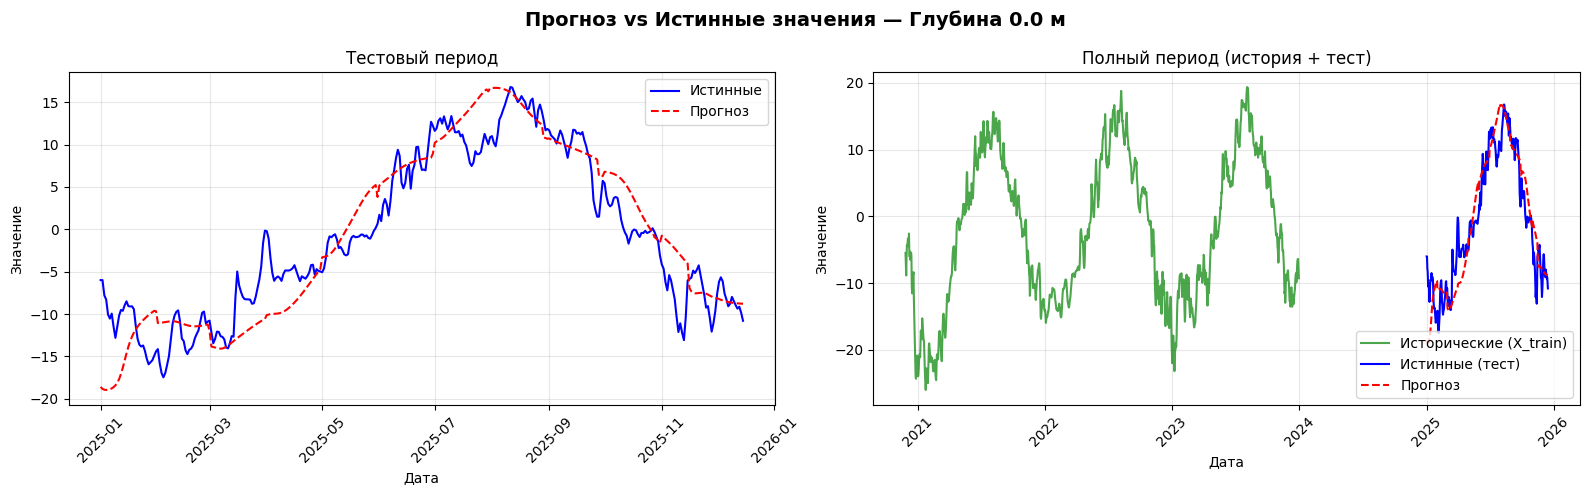

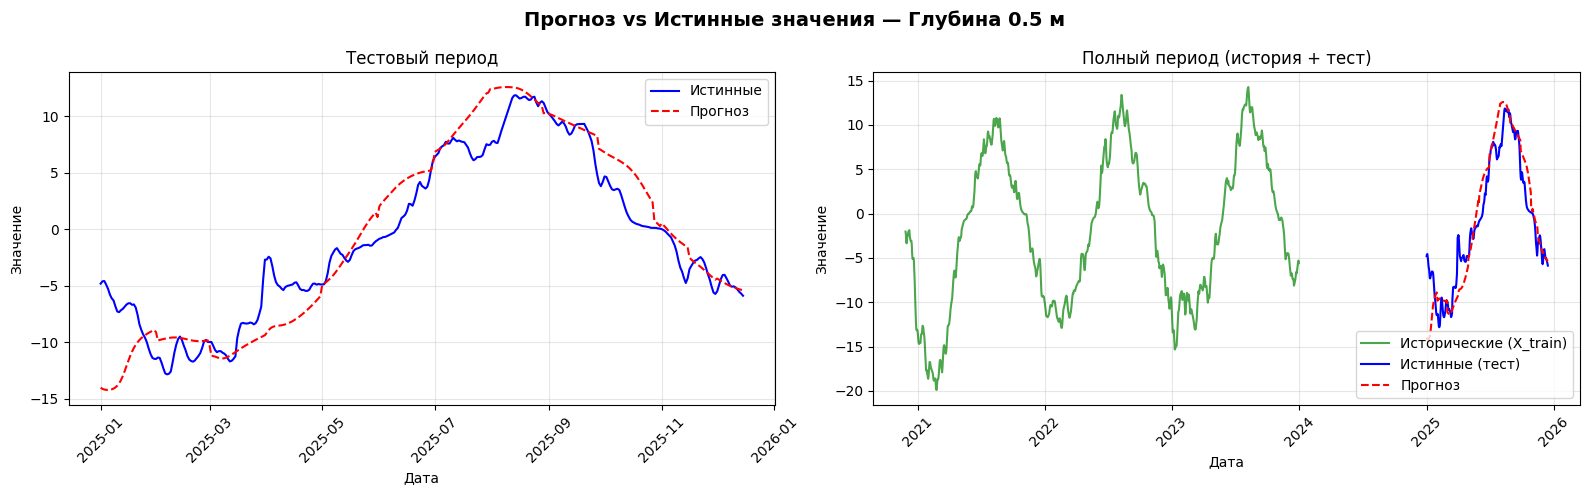

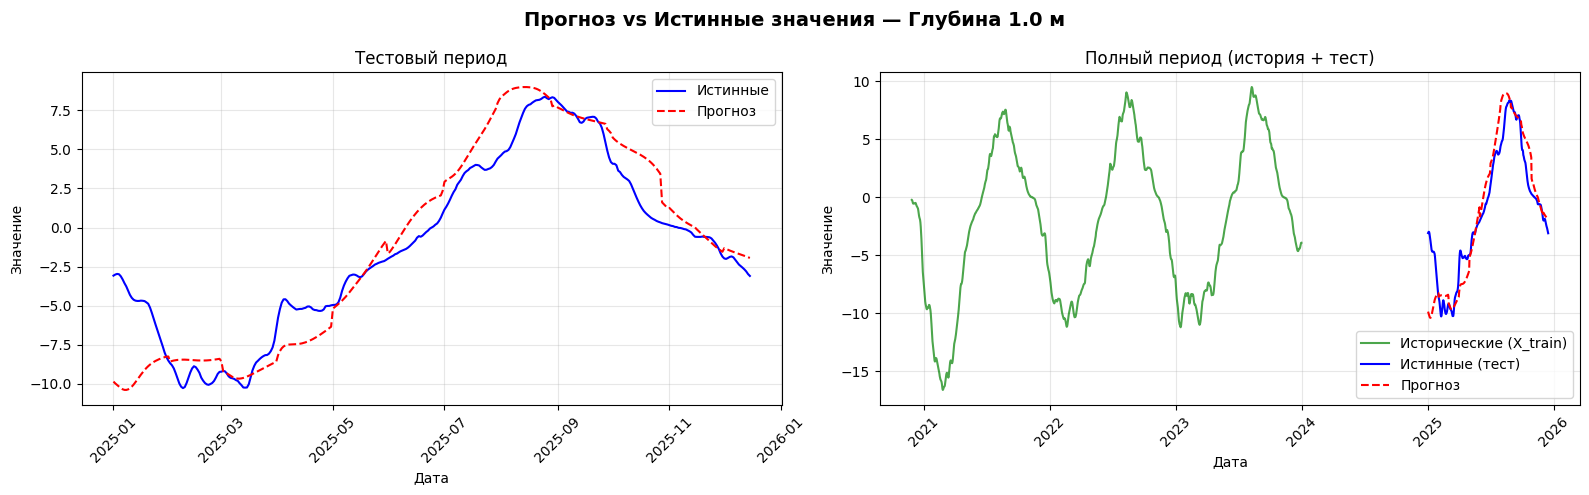

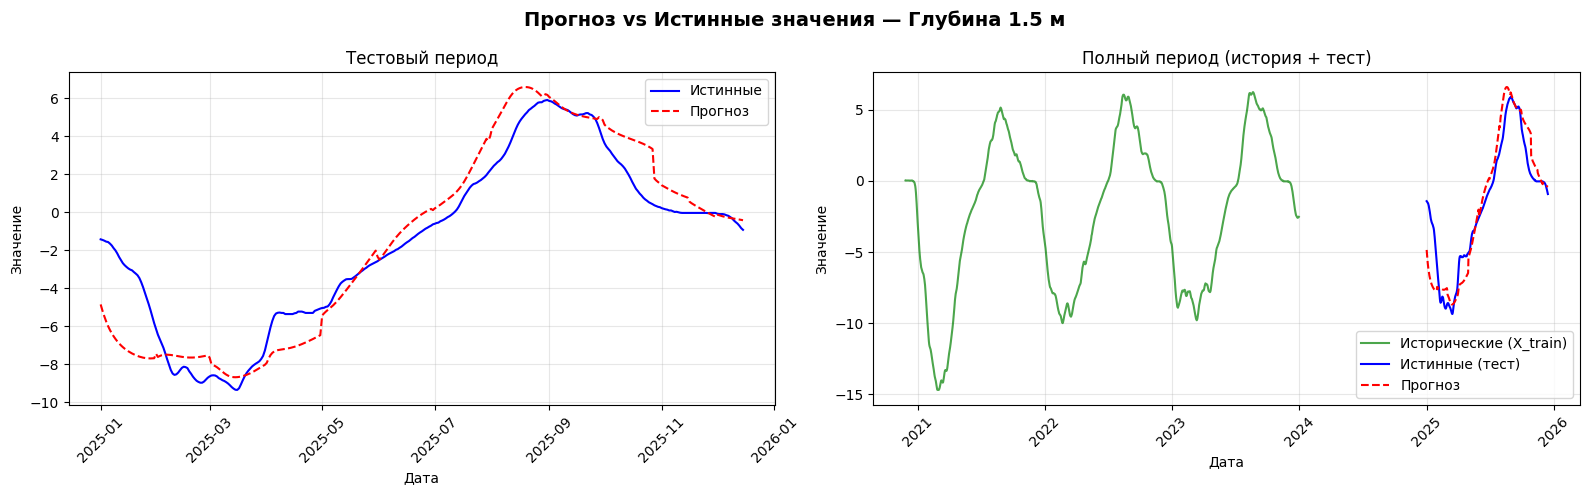

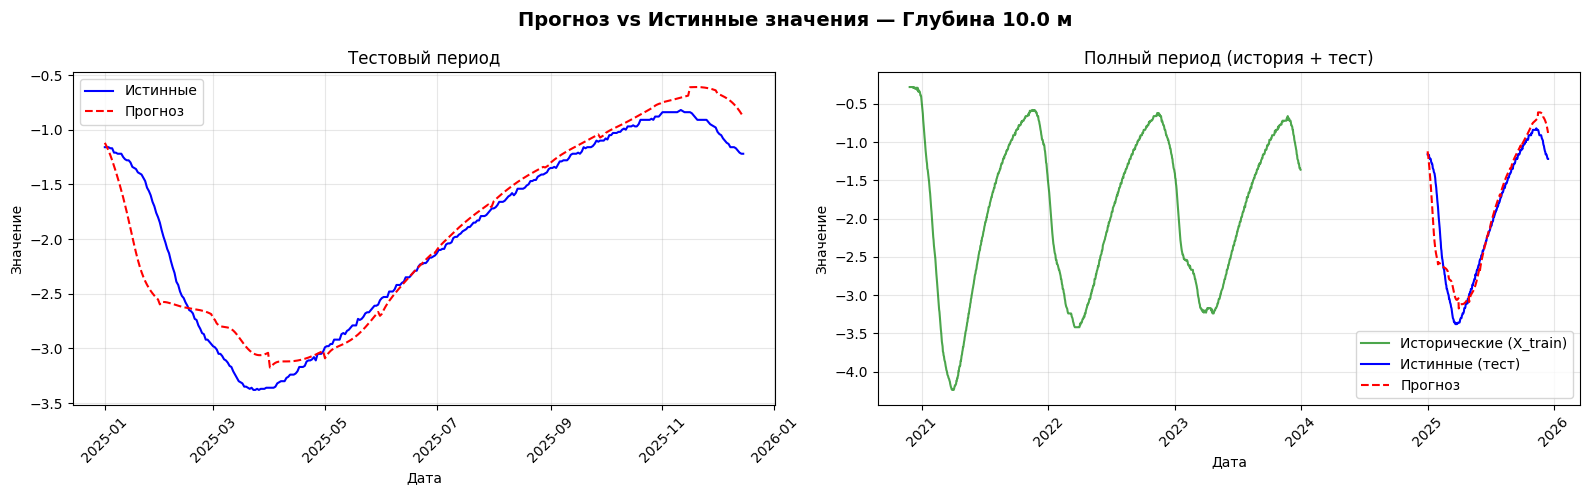

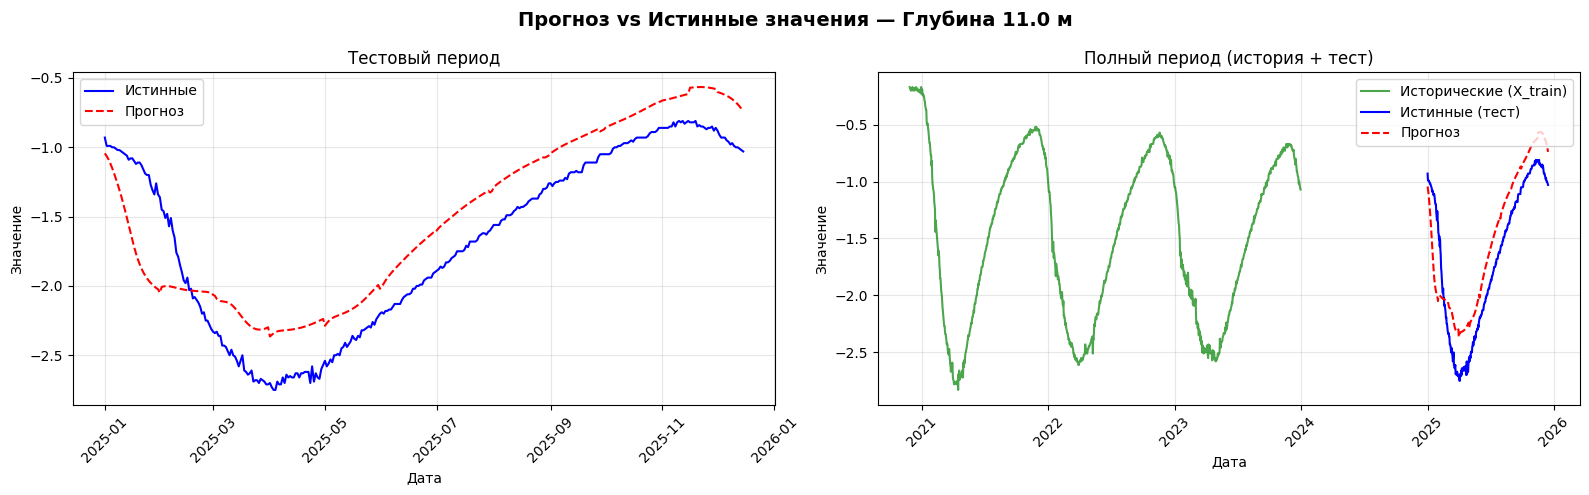

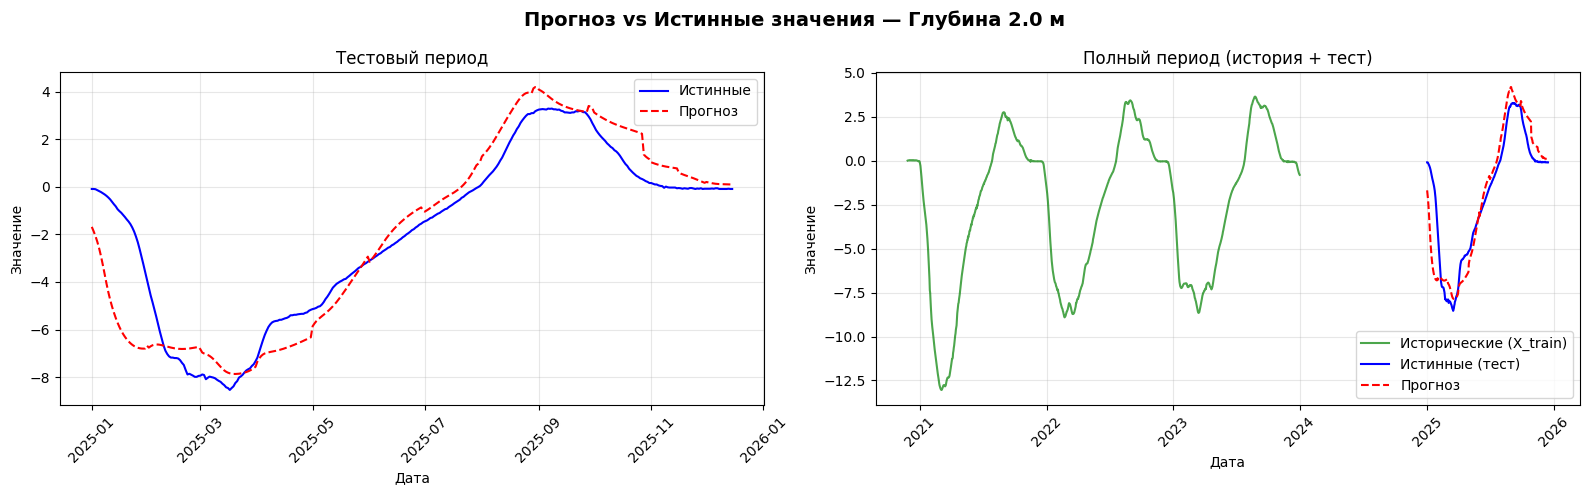

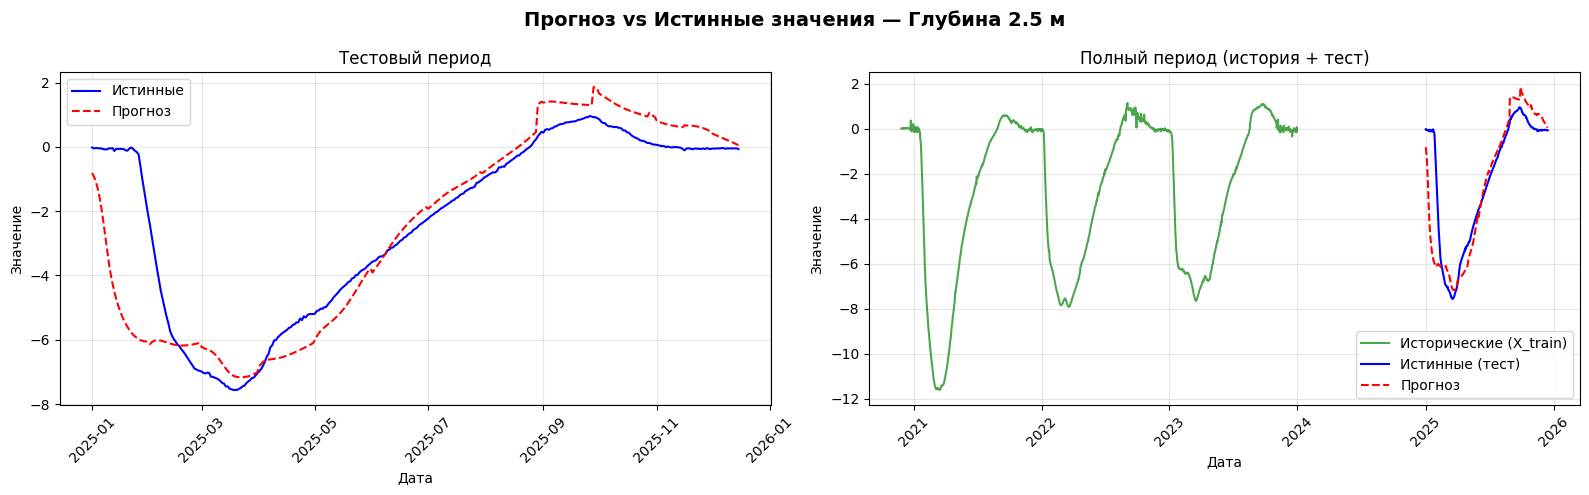

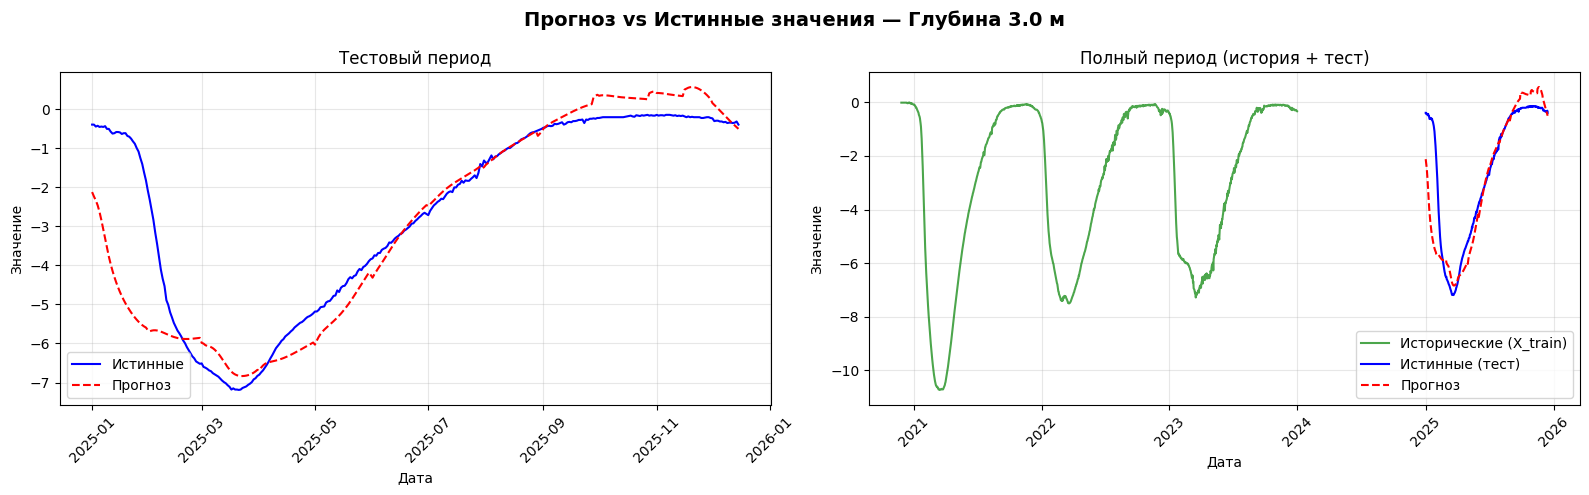

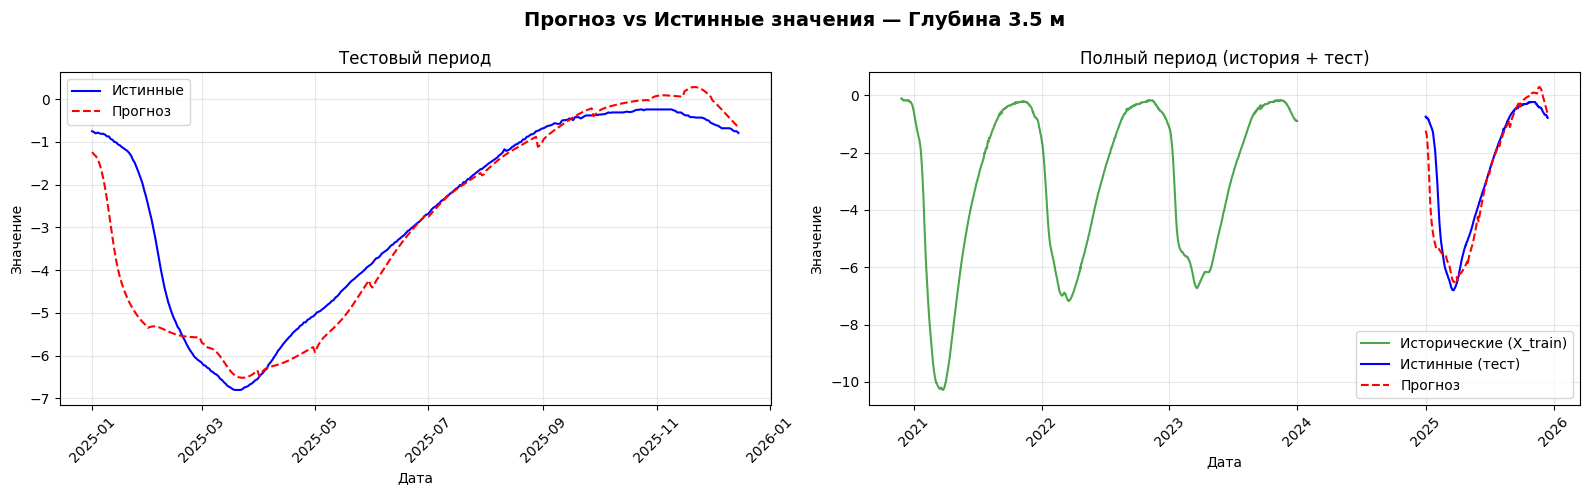

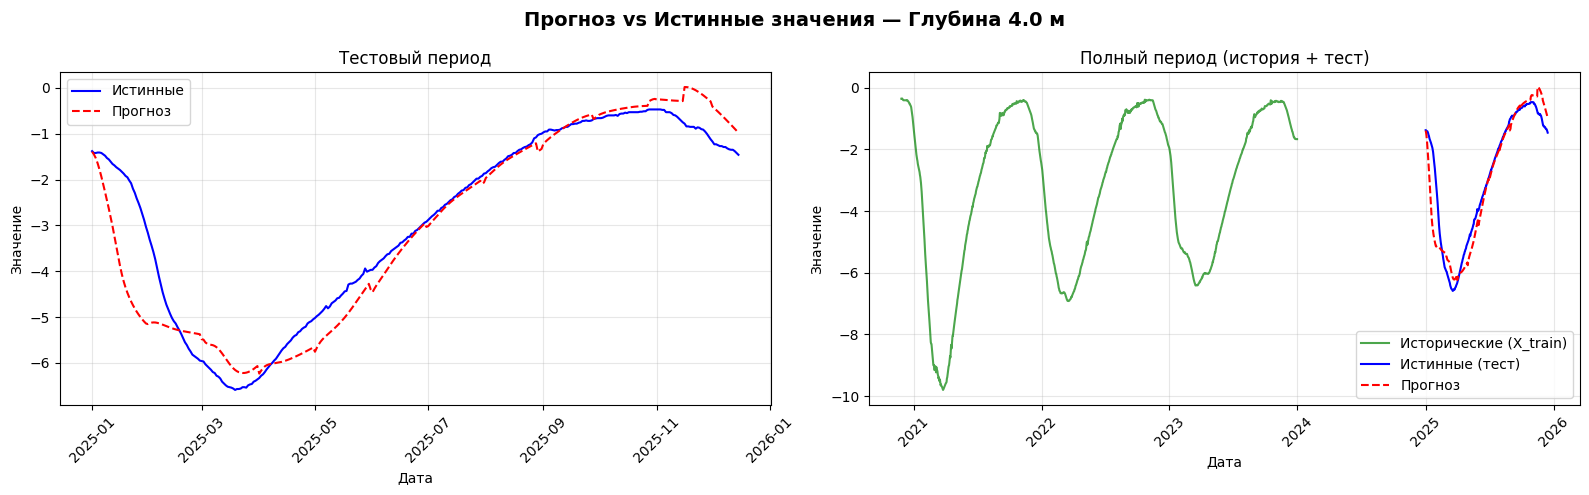

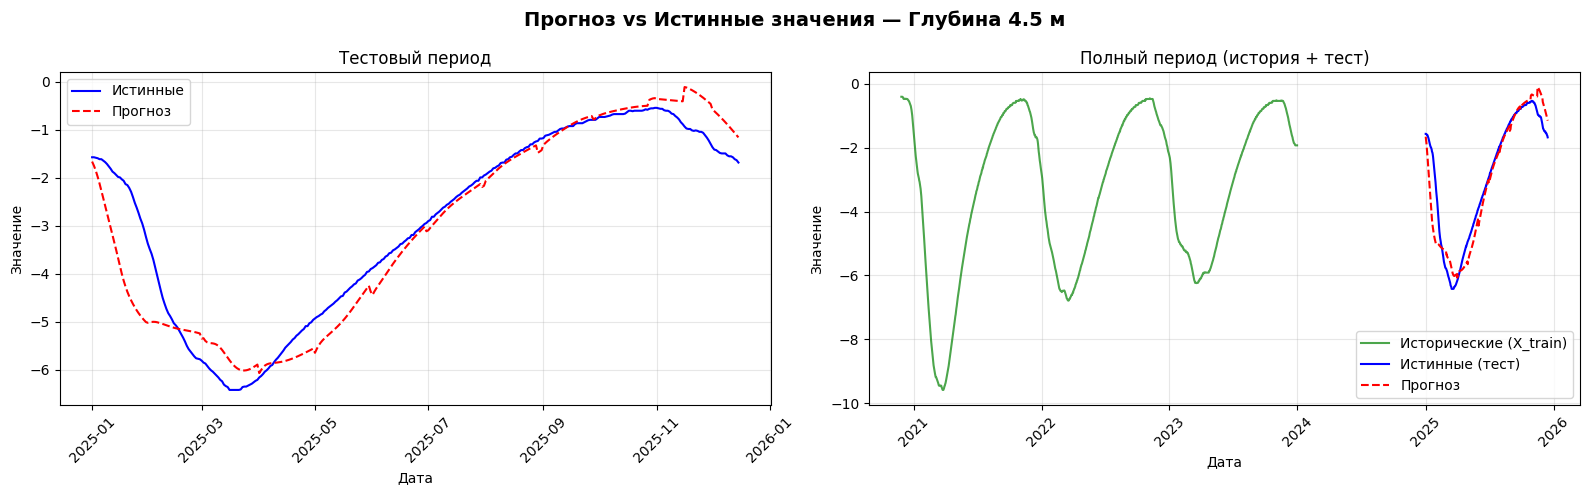

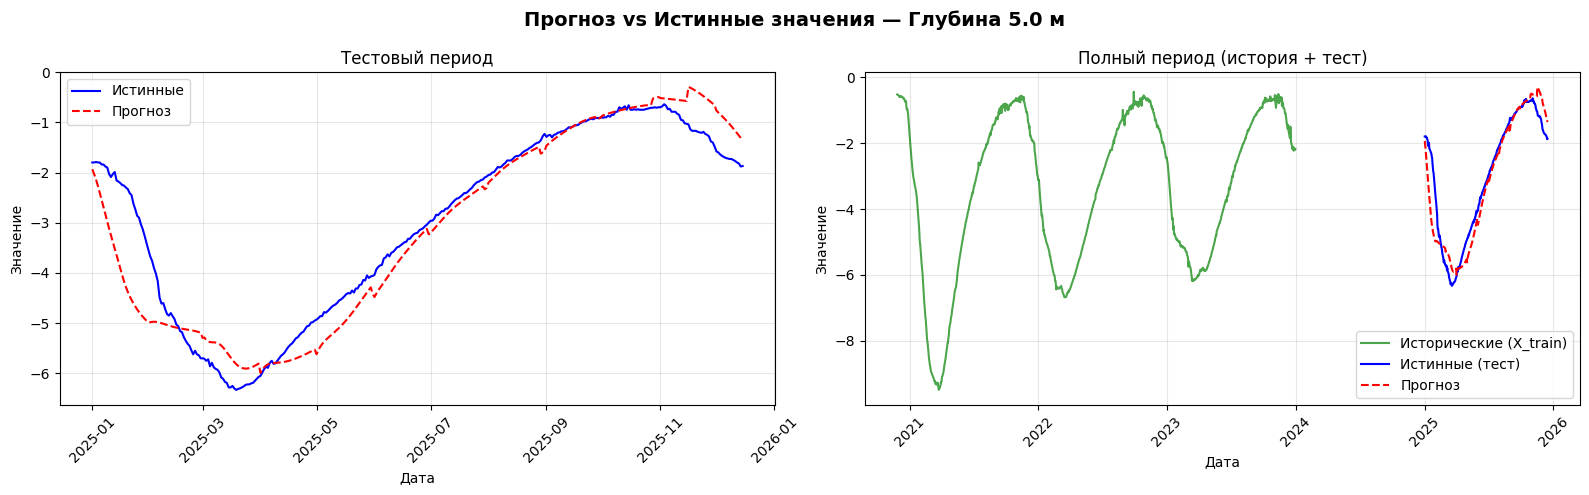

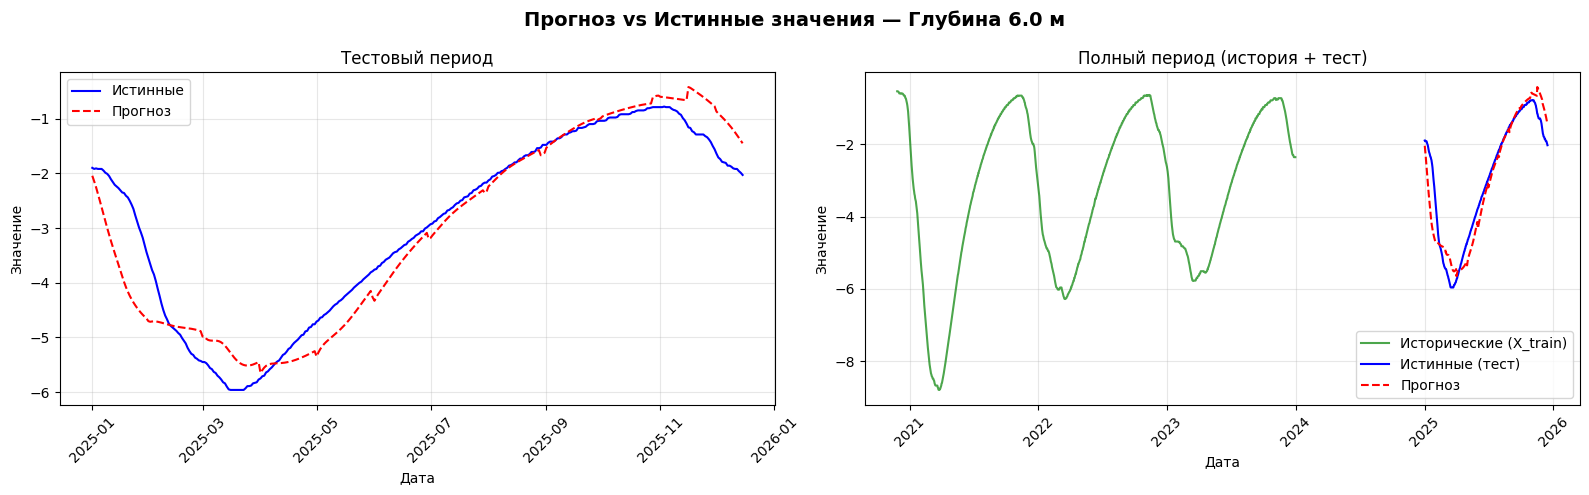

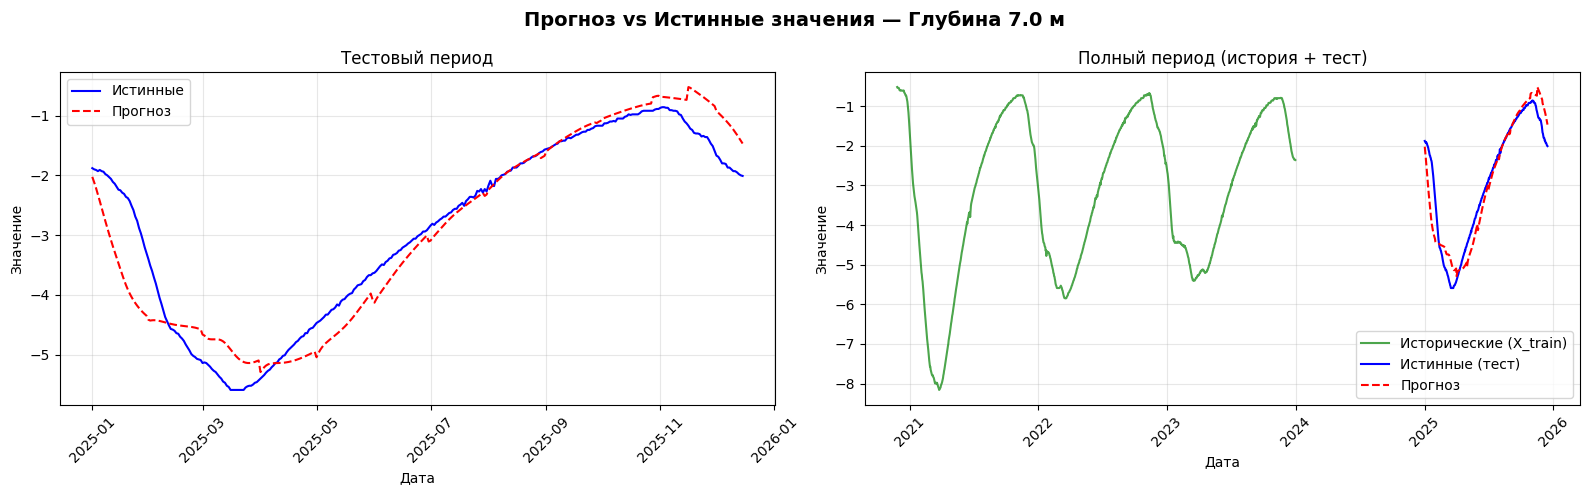

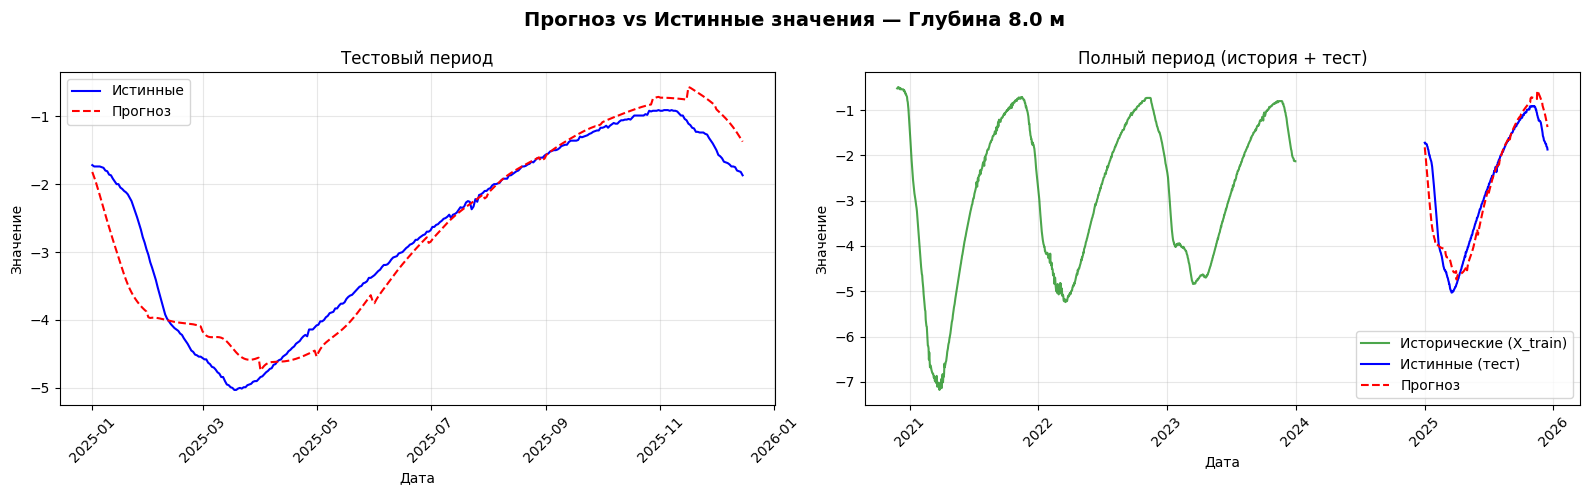

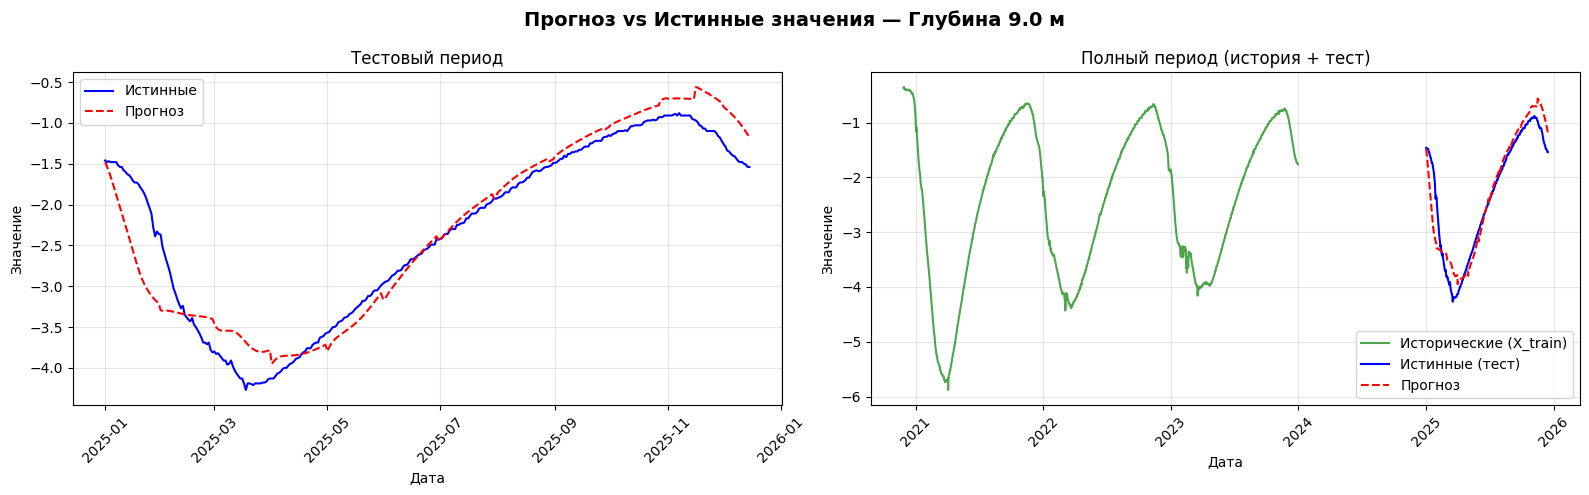

In [277]:
from src.visualization import plot_forecast_with_train
import pandas as pd

from darts.metrics import mae, rmse


actual_series = test_targets
depth_values = []
for ts in actual_series:
    depth_val = ts.static_covariates['depth_val'].iloc[0]
    depth_values.append(depth_val)

records = []
for depth, pred, actual in zip(depth_values, predictions, actual_series):
    mae_val = mae(actual, pred)
    rmse_val = rmse(actual, pred)
    records.append({
        'Depth, m': depth,
        'MAE': mae_val,
        'RMSE': rmse_val,
    })

metrics_df = pd.DataFrame(records)
print("Метрики по глубинам:")
print(metrics_df.to_string(index=False, float_format="%.3f"))

print("\nСредние метрики:")
avg = metrics_df[['MAE','RMSE']].mean()
print(f"MAE  = {avg['MAE']:.3f}")
print(f"RMSE = {avg['RMSE']:.3f}")

for i, depth in enumerate(depth_values):
    actual_ts = actual_series[i]
    pred_ts = predictions[i]

    train_ts = train_targets[i]
    val_ts = target_scaler.inverse_transform(val_scaled_targets)[i]
    train_val_ts = train_ts.append(val_ts)

    X_train = pd.Series(
        train_ts.values().flatten(),
        index=train_ts.time_index
    )
    y_true = pd.Series(
        actual_ts.values().flatten(),
        index=actual_ts.time_index
    )
    y_pred = pd.Series(
        pred_ts.values().flatten(),
        index=pred_ts.time_index
    )

    plot_forecast_with_train(
        X_train=X_train,
        y_true=y_true,
        y_pred=y_pred,
        title=f"Прогноз vs Истинные значения — Глубина {depth} м"
    )


In [278]:
from darts.explainability import TFTExplainer


explainer = TFTExplainer(
    model,
    background_series=val_scaled_targets[0],
    background_past_covariates=combined_past[0],
    background_future_covariates=combined_future[0]
)
explainability_result = explainer.explain()

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 14.93it/s]


In [279]:
import pandas as pd
from IPython.display import display

raw_importances = explainability_result.get_feature_importances()
tables = dict()

for component_name, df_importance in raw_importances.items():

    if isinstance(df_importance, list):
        df_importance = df_importance[0]


    mean_importance = df_importance.mean(axis=0)

    df_component = pd.DataFrame({
        "Признак": mean_importance.index,
        "Важность (%)": mean_importance.values
    })

    if component_name in tables:
        tables[component_name].append(df_component)
    else:
        tables[component_name] = [df_component]

for key in tables:
    print(f"\nКАТЕГОРИЯ ПРИЗНАКОВ: {key.upper()}")
    tabel = tables[key]

    final_table = pd.concat(tabel, ignore_index=True)

    final_table = final_table.sort_values(by="Важность (%)", ascending=False)

    styled_table = (
        final_table.style
        .format({"Важность (%)": "{:.2f}%"})
        .bar(
            subset=["Важность (%)"],
            color="#d6e4ff",
            vmin=0,
            vmax=final_table["Важность (%)"].max()
        )
        .hide(axis='index')
    )

    display(styled_table)



КАТЕГОРИЯ ПРИЗНАКОВ: ENCODER_IMPORTANCE


Признак,Важность (%)
day_of_year_futcov,46.10%
Месяц_cos_futcov,12.30%
Год_futcov,7.90%
add_relative_index_futcov,5.80%
air_temp_pastcov,5.50%
days_since_start_futcov,4.70%
Месяц_sin_futcov,4.10%
Месяц_futcov,4.00%
temperature_target,3.20%
is_anomaly_pastcov,2.50%



КАТЕГОРИЯ ПРИЗНАКОВ: DECODER_IMPORTANCE


Признак,Важность (%)
Год_futcov,19.80%
Месяц_futcov,19.10%
add_relative_index_futcov,15.70%
day_of_year_sin_futcov,13.20%
day_of_year_futcov,10.80%
Месяц_cos_futcov,8.90%
День_futcov,5.80%
days_since_start_futcov,3.20%
day_of_year_cos_futcov,2.30%
Месяц_sin_futcov,1.20%



КАТЕГОРИЯ ПРИЗНАКОВ: STATIC_COVARIATES_IMPORTANCE


Признак,Важность (%)
depth_id_statcov,86.70%
depth_val_statcov,13.30%
